# BeatMetrics — Spotify Music Analysis Dashboard
  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Plotly, Streamlit  
**Dataset:** Spotify 1 Million Tracks (Kaggle)

## Project Overview
Analysis of 1M+ Spotify tracks to uncover patterns in music across genres, decades, and audio features like energy, danceability, and mood.

## Objectives
- Analyze music trends across 2000–2023
- Identify top genres, artists, and tracks  
- Understand audio feature correlations
- Build an interactive filterable dashboard

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('spotify_data.csv')
df = df.drop(columns=['Unnamed: 0'])
df = df.dropna(subset=['artist_name', 'track_name'])
df['duration_min'] = round(df['duration_ms'] / 60000, 2)
df['decade'] = (df['year'] // 10) * 10

print("Shape:", df.shape)
print("Years:", df['year'].min(), "to", df['year'].max())
print("Genres:", df['genre'].nunique())
df.head()

Shape: (1159748, 21)
Years: 2000 to 2023
Genres: 82


,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,duration_min,decade
0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,...,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3,4.00,2010
1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,...,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4,3.61,2010
2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,...,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4,2.65,2010
3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,...,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4,5.07,2010
4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,...,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4,4.07,2010


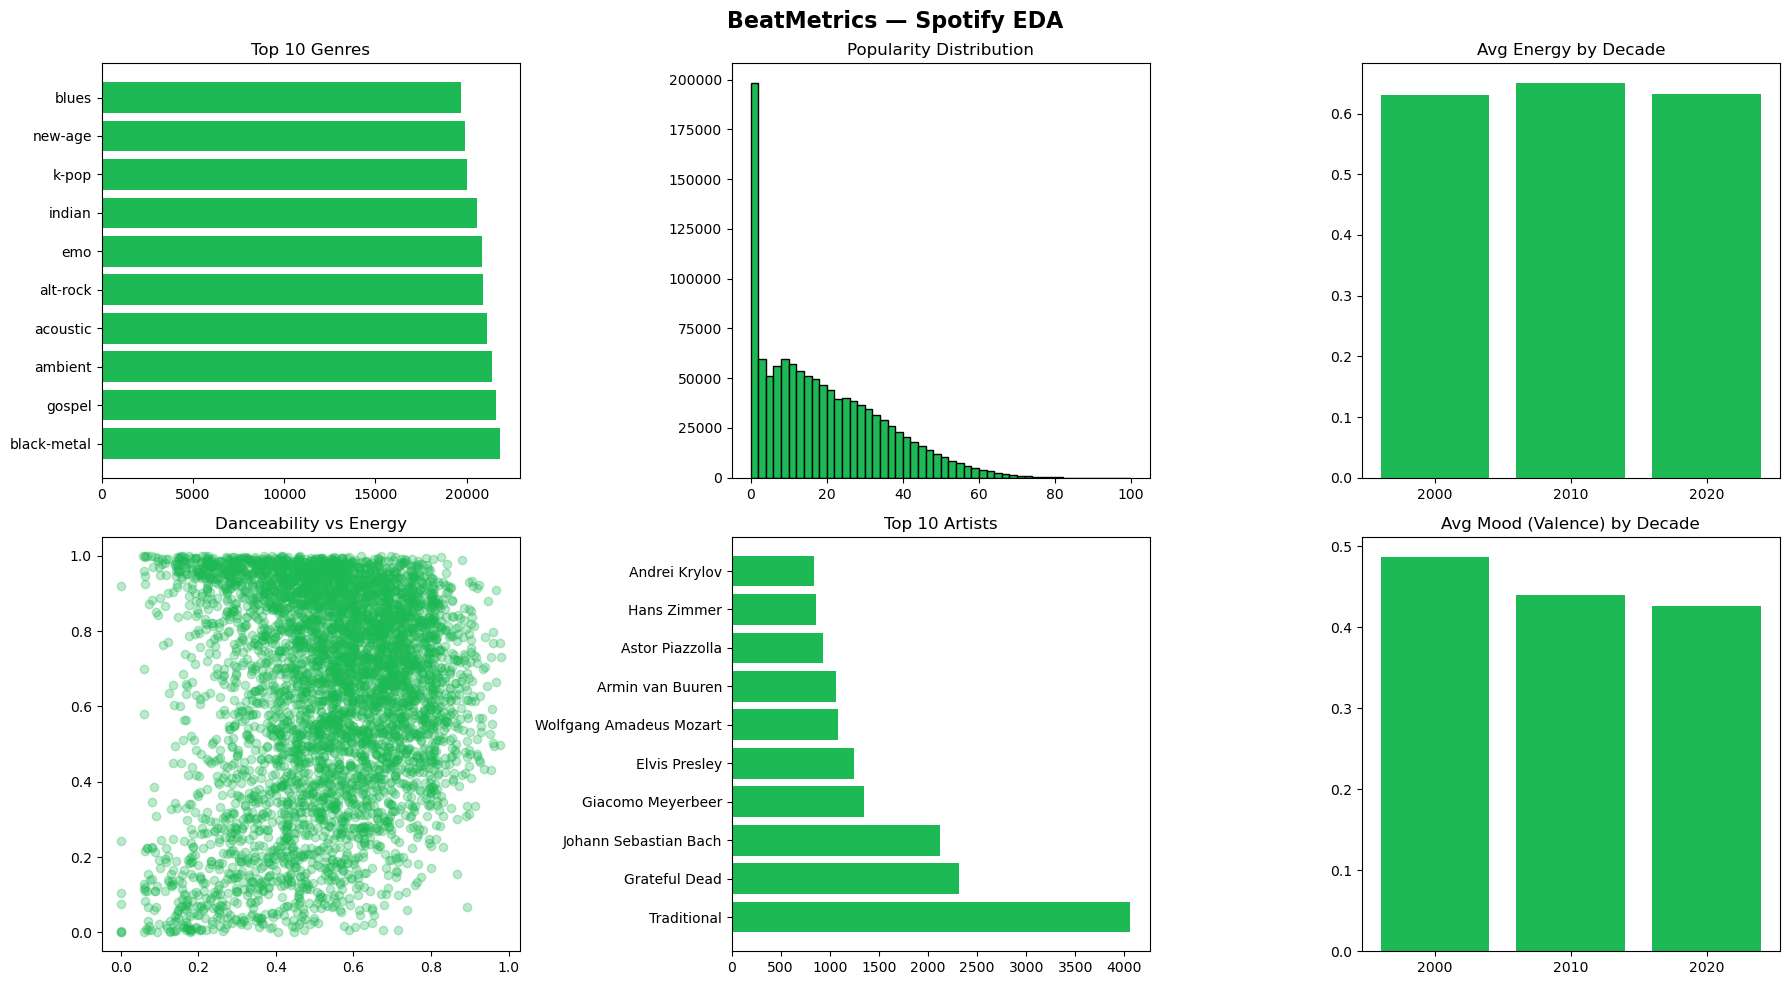

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('BeatMetrics — Spotify EDA', fontsize=16, fontweight='bold')

# 1. Top 10 Genres
genre_counts = df['genre'].value_counts().head(10)
axes[0,0].barh(genre_counts.index, genre_counts.values, color='#1DB954')
axes[0,0].set_title('Top 10 Genres')

# 2. Popularity Distribution
axes[0,1].hist(df['popularity'], bins=50, color='#1DB954', edgecolor='black')
axes[0,1].set_title('Popularity Distribution')

# 3. Avg Energy by Decade
decade_energy = df.groupby('decade')['energy'].mean()
axes[0,2].bar(decade_energy.index.astype(str), decade_energy.values, color='#1DB954')
axes[0,2].set_title('Avg Energy by Decade')

# 4. Danceability vs Energy
sample = df.sample(5000, random_state=42)
axes[1,0].scatter(sample['danceability'], sample['energy'], alpha=0.3, color='#1DB954')
axes[1,0].set_title('Danceability vs Energy')

# 5. Top 10 Artists
top_artists = df['artist_name'].value_counts().head(10)
axes[1,1].barh(top_artists.index, top_artists.values, color='#1DB954')
axes[1,1].set_title('Top 10 Artists')

# 6. Mood by Decade
decade_valence = df.groupby('decade')['valence'].mean()
axes[1,2].bar(decade_valence.index.astype(str), decade_valence.values, color='#1DB954')
axes[1,2].set_title('Avg Mood (Valence) by Decade')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

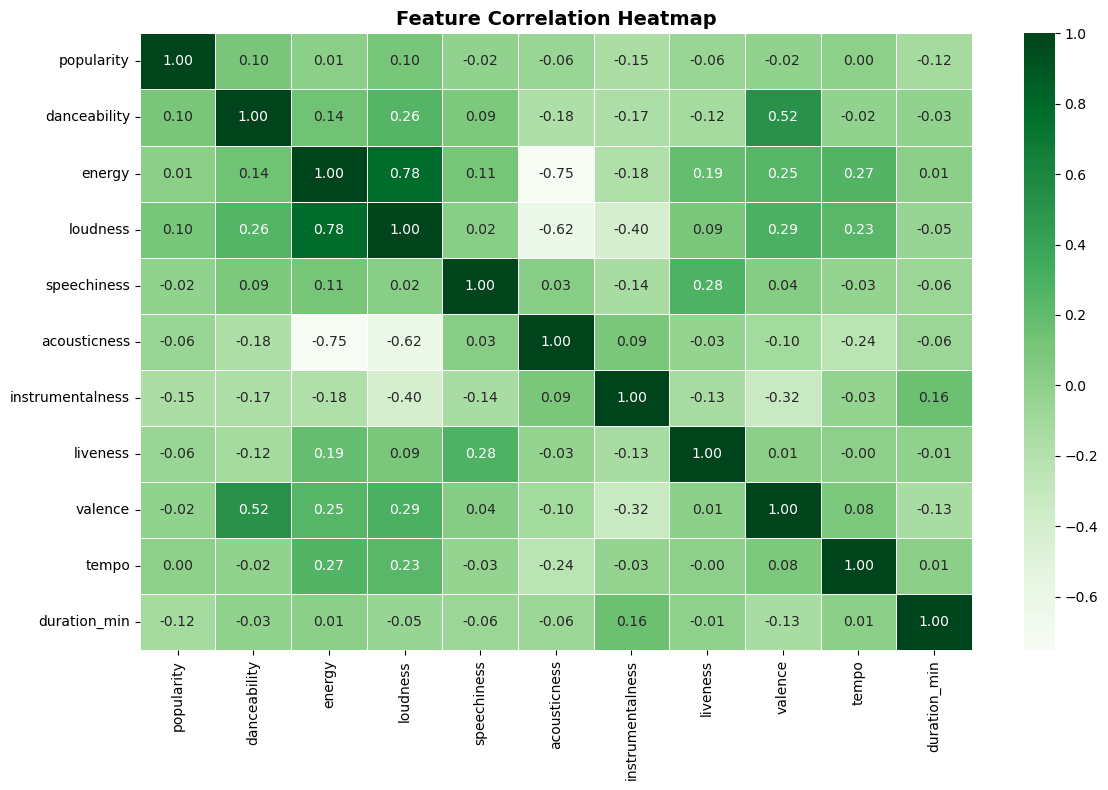

In [6]:
plt.figure(figsize=(12, 8))
numeric_cols = ['popularity', 'danceability', 'energy', 'loudness',
                'speechiness', 'acousticness', 'instrumentalness',
                'liveness', 'valence', 'tempo', 'duration_min']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Greens', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()